**Deep Learning Framework for Leaf Disease Detection and Crop Damage Assessment**

In [1]:
pip install tensorflow-addons==0.22.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50, VGG16, EfficientNetB0, InceptionV3, DenseNet121
from keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cv2
from keras.applications import imagenet_utils

In [3]:
# Load dataset
data_dir = 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage'  # Path to the PlantVillage dataset
image_size = (224, 224)

In [4]:
un_healthy_images_list = ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Target_Spot',
                                     'Tomato_Late_blight', 'Tomato_Bacterial_spot','Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot',
                                     'Tomato_Early_blight', 'Tomato_Leaf_Mold']

un_healthy_images_list

['Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Target_Spot',
 'Tomato_Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Early_blight',
 'Tomato_Leaf_Mold']

In [5]:

from PIL import Image

def is_image_file(filename):
    filename = filename.lower()
    return filename.endswith(".jpg") or filename.endswith(".jpeg") or filename.endswith(".png")

def load_dataset(data_dir, image_size, main_dir="C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage"):
    image_data = []
    # labels = []

    for dir in data_dir:
      path = os.path.join(main_dir, dir)
      # print(path)

      imageNames = os.listdir(path)
      # print(imageNames)
      for image in imageNames:
        if not is_image_file(image):
              continue  # Skip non-image files

        image_path = os.path.join(path, image)
        imgs = Image.open(image_path)
        img = np.array(imgs)

        if img is None:
          print(f"Warning: Failed to load image {image}")
          continue  # Skip invalid images

        img = cv2.resize(img, image_size)
        image_data.append(img)
        # labels.append(label)
      # Append the corresponding label

    return np.array(image_data)



In [6]:
data_dir = un_healthy_images_list
image_size = (224, 224)  # Example size
unhealthy_images = load_dataset(data_dir, image_size)
print(unhealthy_images)  # Prints the labels corresponding to each image

[[[[154 144 143]
   [159 149 148]
   [152 142 141]
   ...
   [130 114 114]
   [118 102 102]
   [ 95  79  79]]

  [[160 150 149]
   [161 151 150]
   [148 138 137]
   ...
   [122 106 106]
   [118 102 102]
   [108  92  92]]

  [[155 145 144]
   [159 149 148]
   [149 139 138]
   ...
   [116 100 100]
   [108  92  92]
   [104  88  88]]

  ...

  [[152 141 139]
   [154 143 141]
   [151 140 138]
   ...
   [117  99  97]
   [113  95  93]
   [108  91  89]]

  [[143 132 130]
   [159 148 146]
   [139 128 126]
   ...
   [113  95  93]
   [112  94  92]
   [111  94  92]]

  [[150 139 137]
   [142 131 129]
   [141 130 128]
   ...
   [110  92  90]
   [110  92  90]
   [112  94  92]]]


 [[[146 140 144]
   [156 150 154]
   [163 157 161]
   ...
   [115 104 108]
   [106  95  99]
   [107  96 100]]

  [[139 132 137]
   [147 141 145]
   [148 142 146]
   ...
   [126 115 119]
   [126 115 119]
   [121 110 114]]

  [[148 142 146]
   [142 136 140]
   [147 141 145]
   ...
   [123 112 116]
   [115 104 108]
   [115 104

In [7]:
unhealthy_images.shape

(12744, 224, 224, 3)

In [8]:
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(unhealthy_images), 1000, replace=False)
unhealthy_images_resized = unhealthy_images[indices]
unhealthy_images_resized.shape

(1000, 224, 224, 3)

In [9]:
unhealthy_labels = np.ones(1000)


In [10]:
healthy_images_list = ["Tomato_healthy"]
healthy_images_list

['Tomato_healthy']

In [11]:
data_dir = healthy_images_list
# print(data_dir)
image_size = (224, 224)  # Example size
healthy_images = load_dataset(data_dir, image_size)
healthy_images

array([[[[132, 131, 137],
         [113, 112, 118],
         [ 99,  98, 104],
         ...,
         [116, 113, 124],
         [134, 131, 142],
         [120, 117, 128]],

        [[116, 115, 121],
         [119, 118, 123],
         [127, 126, 132],
         ...,
         [115, 112, 123],
         [112, 108, 120],
         [124, 121, 132]],

        [[139, 138, 144],
         [137, 136, 142],
         [130, 129, 135],
         ...,
         [111, 107, 118],
         [113, 110, 121],
         [124, 121, 132]],

        ...,

        [[ 69,  73,  77],
         [ 80,  82,  87],
         [ 67,  70,  75],
         ...,
         [ 83,  83,  93],
         [ 74,  74,  84],
         [ 78,  78,  88]],

        [[ 68,  71,  76],
         [ 66,  69,  74],
         [ 58,  61,  66],
         ...,
         [ 76,  76,  86],
         [ 78,  78,  88],
         [ 90,  90, 100]],

        [[ 70,  73,  78],
         [ 56,  59,  64],
         [ 56,  59,  64],
         ...,
         [ 75,  75,  85],
        

In [12]:
healthy_images.shape

(1591, 224, 224, 3)

In [13]:
healthy_labels = np.zeros(1591)
healthy_labels

array([0., 0., 0., ..., 0., 0., 0.])

In [14]:
images = np.concatenate((healthy_images, unhealthy_images_resized), axis=0)
labels = np.concatenate((healthy_labels, unhealthy_labels), axis=0)
print(images.shape)
print(labels.shape)

(2591, 224, 224, 3)
(2591,)


In [15]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

In [17]:
dataset_path = "C:\\Users\\HP\\OneDrive\\Desktop\\project\\Chapter4 Data\\Code\\PlantVillage\\PlantVillage"
img_height, img_width = 224, 224  # Image size (adjust if needed)
batch_size = 32
epochs = 40

In [18]:
# Initialize the data generators
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2  # Use 20% of the data for validation
)

# Training generator (80% of data)
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',  # Set as training data
    shuffle=True
)
# Validation generator (20% of data)
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',  # Set as validation data
    shuffle=True
)

Found 13053 images belonging to 11 classes.
Found 3258 images belonging to 11 classes.


In [19]:
# Assuming test data is in a separate 'test' folder in the main dataset path
test_generator = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    os.path.join(dataset_path, 'test'),
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 300 images belonging to 10 classes.


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 111, 111, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 109, 109, 64)     2

In [21]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


Epoch 1/40
407/407 [==============================] - 924s 2s/step - loss: 0.8438 - accuracy: 0.7415 - val_loss: 17.7784 - val_accuracy: 0.2215
Epoch 2/40
407/407 [==============================] - 838s 2s/step - loss: 0.5555 - accuracy: 0.8343 - val_loss: 2.8238 - val_accuracy: 0.7373
Epoch 3/40
407/407 [==============================] - 843s 2s/step - loss: 0.4225 - accuracy: 0.8749 - val_loss: 0.7650 - val_accuracy: 0.7887
Epoch 4/40
407/407 [==============================] - 754s 2s/step - loss: 0.3299 - accuracy: 0.9047 - val_loss: 2.4726 - val_accuracy: 0.6928
Epoch 5/40
407/407 [==============================] - 766s 2s/step - loss: 0.2617 - accuracy: 0.9217 - val_loss: 1.0724 - val_accuracy: 0.7618
Epoch 6/40
407/407 [==============================] - 812s 2s/step - loss: 0.2238 - accuracy: 0.9354 - val_loss: 0.6424 - val_accuracy: 0.8589
Epoch 7/40
407/407 [==============================] - 816s 2s/step - loss: 0.3472 - accuracy: 0.8967 - val_loss: 1.2633 - val_accuracy: 0.640

In [24]:
# Evaluate on test data (optional)
train_loss, train_accuracy = model.evaluate(train_generator)
print(f'Train accuracy: {train_accuracy:.2f}, Train loss: {train_loss:.2f}')


408/408 [==============================] - 112s 273ms/step - loss: 0.0408 - accuracy: 0.9880
Test accuracy: 0.99, Test loss: 0.04


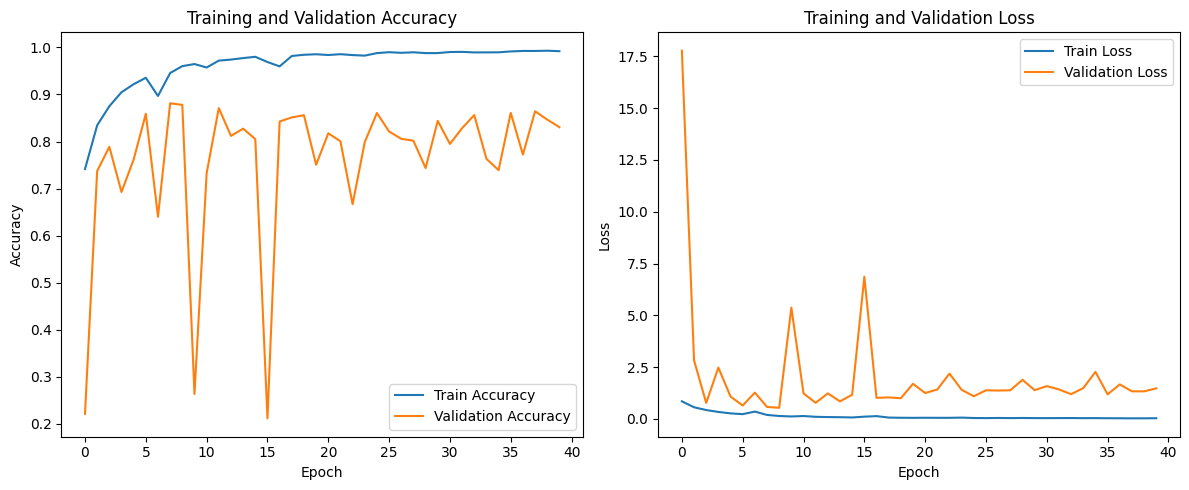

In [25]:
import matplotlib.pyplot as plt

# Plot accuracy and loss over epochs
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()
